## Results of Host Prediction
### Dataset: BVBRC proteome, Virus Genus Split

**Classification**: Multi-class

**\# classes**: 8

**\# proteins in dataset** = 12,913

**\# train samples** = 6768

**\# validation samples** = 3072

**\# test samples** = 3072

In [1]:
import seaborn

In [2]:
seaborn.__version__

'0.13.2'

In [3]:
import sys
import os
from pathlib import Path
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", ".."))
sys.path

['/home/blessyantony/miniconda3/envs/haven/lib/python311.zip',
 '/home/blessyantony/miniconda3/envs/haven/lib/python3.11',
 '/home/blessyantony/miniconda3/envs/haven/lib/python3.11/lib-dynload',
 '',
 '/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../../../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../..']

In [4]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import mannwhitneyu, wilcoxon, ranksums, iqr

from src.utils import utils, evaluation_utils, visualization_utils

In [5]:
input_filepath = os.path.join(os.getcwd(), "..","..", "..", "..", "input/data/bvbrc/BVBRC_reference_genome_20260429_proteome_proteins_host_prevalence_gte_onepercent.csv")
input_df = pd.read_csv(input_filepath)

In [6]:
def classwise_auprc_analysis(output_filepaths, figure_output_filepath=None):
    itr_col = "itr"
    experiment_col = "experiment"
    y_true_col = "y_true"
    auprc_results = []
    for model, output_filepath in output_filepaths.items():
        df = pd.read_csv(output_filepath, index_col=0)
        df.fillna(0, inplace=True)
        print(f"Read output {model} = {df.shape}")
        
        cols = df.columns
        itrs = df[itr_col].unique()
    
        for itr in itrs:
            df_itr = df[df[itr_col] == itr]
            _, auprcs_df = evaluation_utils.compute_class_auprc(df_itr, y_pred_columns=classes, y_true_col=y_true_col)
            auprcs_df["model"] = model
            auprcs_df["itr"] = itr
            auprc_results.append(auprcs_df)
    metadata = utils.compute_class_distribution(df_itr, y_true_col, format=False)
    metadata_formatted = utils.compute_class_distribution(df_itr, y_true_col, format=True)
    metadata_sorted = {}
    for k, v in metadata.items():
        metadata_sorted[metadata_formatted[k]] = v
    
    auprc_results_df = pd.concat(auprc_results, ignore_index=True)
    auprc_results_df.replace({"class":metadata_formatted}, inplace=True)
    sns.set_context("paper")
    sns.axes_style("whitegrid")
    
    FIGURE_CONFIG = {
        "figsize": (12, 6),
        "xtick.labelsize": 14,
        "ytick.labelsize": 14    
    }
    
    color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=auprc_results_df["model"].nunique())
    
    visualization_utils.pre_plot_config(FIGURE_CONFIG)
    ax = sns.boxplot(data=auprc_results_df, x="class", y="auprc", hue="model", 
                     order=metadata_sorted, linewidth=1.5, fliersize=5, linecolor="black",
                     palette=color_palette)
    
    bg_colors = [ "gray", "white",]
    
    plt.draw()
    
    ax.set_ylim(0, 1)
    ax.set_ylabel("AUPRC", size=14)
    ax.set_xlabel("", size=0, labelpad=0)
    sns.move_legend(ax, "lower center", bbox_to_anchor=(.5, 1), ncol=5, title=None, frameon=False)
    plt.setp(ax.get_legend().get_texts(), fontsize=14)
    visualization_utils.wrap_ticklabels(ax, axis="x")
    
    n_classes = auprc_results_df["class"].nunique()
    for i in range(n_classes):
        ax.axvspan(i - .5, i + .5, color=bg_colors[i%2], alpha=0.2)
    
    if figure_output_filepath:
        visualization_utils.view(figure_output_filepath)
    plt.show()

In [7]:
def macro_and_classwise_auprc_analysis(output_filepaths, classes, figure_output_filepath=None):
    auprc_results = []
    itr_col = "itr"
    experiment_col = "experiment"
    y_true_col = "y_true"
    for model, output_filepath in output_filepaths.items():
        df = pd.read_csv(output_filepath, index_col=0)
        print(f"Read output {model} = {df.shape}")
        df.fillna(0, inplace=True)
        cols = df.columns
        itrs = df[itr_col].unique()
    
        for itr in itrs:
            df_itr = df[df[itr_col] == itr]
            _, auprcs_df = evaluation_utils.compute_class_auprc(df_itr, y_pred_columns=classes, y_true_col=y_true_col)
            auprcs_df = pd.concat([auprcs_df, 
                                   pd.DataFrame({"class": ["Macro-AUPRC"], "auprc": [auprcs_df["auprc"].mean()]})
                                  ], ignore_index=True)
            auprcs_df["model"] = model
            auprcs_df["itr"] = itr
            auprc_results.append(auprcs_df)
    
    metadata = utils.compute_class_distribution(df_itr, y_true_col, format=False)
    metadata_formatted = utils.compute_class_distribution(df_itr, y_true_col, format=True)
    metadata_sorted = {}
    for k, v in metadata.items():
        metadata_sorted[metadata_formatted[k]] = v
    #metadata_sorted["Macro-AUPRC"] = 0
    auprc_results_df = pd.concat(auprc_results, ignore_index=True)
    auprc_results_df.replace({"class": metadata_formatted}, inplace=True)
    models = list(auprc_results_df["model"].unique())
    plt.rcParams['xtick.labelsize'] = 18
    plt.rcParams['ytick.labelsize'] = 18
    plt.rcParams.update({'font.size': 18})
    fig, axs = plt.subplots(1, 2, figsize=(18, 6), sharex=False, sharey=True, gridspec_kw={"width_ratios": [1, 8]})
    color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=auprc_results_df["model"].nunique())

    sns.boxplot(data=auprc_results_df[auprc_results_df["class"] == "Macro-AUPRC"], x="class", y="auprc", hue="model", fill=True,
                palette=color_palette, ax=axs[0],
                linewidth=1.5, fliersize=5, linecolor="black", legend=False)
    
    sns.boxplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", linewidth=1.5, fliersize=5, linecolor="black", order=metadata_sorted, palette=color_palette, ax=axs[1])
    #sns.violinplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", orient="v", order=metadata_sorted, palette=color_palette, ax=axs[1], legend="auto")
    # plt.draw()
    axs[0].set_ylim(0.0, 1)
    axs[1].set_ylim(0.0, 1)
    axs[0].set_ylabel("AUPRC", size=20)
    axs[0].set_xlabel("", size=0, labelpad=0)
    axs[1].set_xlabel("", size=0, labelpad=0)
    sns.move_legend(axs[1], "lower center", bbox_to_anchor=(.35, 1), ncol=5, title=None, frameon=False)
    plt.setp(axs[1].get_legend().get_texts(), fontsize=20)
    #visualization_utils.wrap_ticklabels(axs[0], axis="x")
    visualization_utils.wrap_ticklabels(axs[1], axis="x")

    bg_colors = [ "gray", "white",]
    
    for i in range(len(classes)):
        axs[1].axvspan(i - .5, i + .5, color=bg_colors[i%2], alpha=0.2)
    
    #plt.subplots_adjust(wspace=0.01)
    plt.tight_layout()
    #plt.savefig(figure_output_filepath, dpi=600)
    #plt.subplots_adjust(wspace=-1.5)
    plt.show()
    return auprc_results_df

In [43]:
def macro_and_classwise_auprc_proteome_analysis(output_filepaths, classes, figure_output_filepath=None):
    auprc_results = []
    raw_results = []
    itr_col = "itr"
    y_true_col = "y_true"
    for model, output_filepath in output_filepaths.items():
        raw_df = pd.read_csv(output_filepath, index_col=0)
        print(f"Read output {model} = {raw_df.shape}")
        raw_df = raw_df[["protein_id_name", itr_col, y_true_col] + classes].merge(input_df[["proteome_id", "protein", "protein_id_name", "virus_host_species_tax_id", "virus_genus_tax_name"]], on="protein_id_name", how="left")
        raw_df["model"] = model
        raw_results.append(raw_df)
        df = raw_df[classes + ["proteome_id", "y_true", "itr"]]
        df = df.groupby(["proteome_id", "y_true", "itr"]).agg("mean").reset_index()
        df.fillna(0, inplace=True)
        cols = df.columns
        itrs = df[itr_col].unique()
    
        for itr in itrs:
            df_itr = df[df[itr_col] == itr]
            _, auprcs_df = evaluation_utils.compute_class_auprc(df_itr, y_pred_columns=classes, y_true_col=y_true_col)
            auprcs_df = pd.concat([auprcs_df, 
                                   pd.DataFrame({"class": ["Macro-AUPRC"], "auprc": [auprcs_df["auprc"].mean()]})
                                  ], ignore_index=True)
            auprcs_df["model"] = model
            auprcs_df["itr"] = itr
            auprc_results.append(auprcs_df)
    
    metadata = utils.compute_class_distribution(df_itr, y_true_col, format=False)
    metadata_formatted = utils.compute_class_distribution(df_itr, y_true_col, format=True)
    metadata_sorted = {}
    for k, v in metadata.items():
        metadata_sorted[metadata_formatted[k]] = v
    #metadata_sorted["Macro-AUPRC"] = 0
    auprc_results_df = pd.concat(auprc_results, ignore_index=True)
    auprc_results_df.replace({"class": metadata_formatted}, inplace=True)
    models = list(auprc_results_df["model"].unique())
    plt.rcParams['xtick.labelsize'] = 18
    plt.rcParams['ytick.labelsize'] = 18
    plt.rcParams.update({'font.size': 18})
    fig, axs = plt.subplots(1, 2, figsize=(18, 6), sharex=False, sharey=True, gridspec_kw={"width_ratios": [1, 8]})
    color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=auprc_results_df["model"].nunique())

    sns.boxplot(data=auprc_results_df[auprc_results_df["class"] == "Macro-AUPRC"], x="class", y="auprc", hue="model", fill=True,
                palette=color_palette, ax=axs[0],
                linewidth=1.5, fliersize=5, linecolor="black", legend=False)
    
    sns.boxplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", linewidth=1.5, fliersize=5, linecolor="black", order=metadata_sorted, palette=color_palette, ax=axs[1])
    #sns.violinplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", orient="v", order=metadata_sorted, palette=color_palette, ax=axs[1], legend="auto")
    # plt.draw()
    axs[0].set_ylim(0.0, 1)
    axs[1].set_ylim(0.0, 1)
    axs[0].set_ylabel("AUPRC", size=20)
    axs[0].set_xlabel("", size=0, labelpad=0)
    axs[1].set_xlabel("", size=0, labelpad=0)
    sns.move_legend(axs[1], "lower center", bbox_to_anchor=(.35, 1), ncol=5, title=None, frameon=False)
    plt.setp(axs[1].get_legend().get_texts(), fontsize=20)
    #visualization_utils.wrap_ticklabels(axs[0], axis="x")
    visualization_utils.wrap_ticklabels(axs[1], axis="x")

    bg_colors = [ "gray", "white",]
    
    for i in range(len(classes)):
        axs[1].axvspan(i - .5, i + .5, color=bg_colors[i%2], alpha=0.2)
    
    #plt.subplots_adjust(wspace=0.01)
    plt.tight_layout()
    #plt.savefig(figure_output_filepath, dpi=600)
    #plt.subplots_adjust(wspace=-1.5)
    plt.show()
    return pd.concat(raw_results)

In [44]:
output_filepaths = {
    "BLAST": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_genus_host_species_vertebrates_t0.01_c8/20260518/host_multi/virus_genus_split/homology/virus_host_species_tax_id_multi_blast_blast_output.csv"),
    "HAVEN": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/bvbrc_virus_genus_host_species_vertebrates_t0.01_c8/20260518/host_multi/virus_genus_split/haven/mlm_tfenc_l6_h8_lr1e-4_uniref90viridae_vs30_virus_genus_split_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr1e-4_output.csv"),
}

classes = ["Human", "Chicken", "Pig", "Domestic cattle", "Norway rat", "Horse", "Wolf", "Boa"]

## Protein-level Evaluation

Read output BLAST = (27078, 14)
Read output HAVEN = (8203, 11)


/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../../../../src/utils/visualization_utils.py:119: UserWarning: set_ticklabels() should

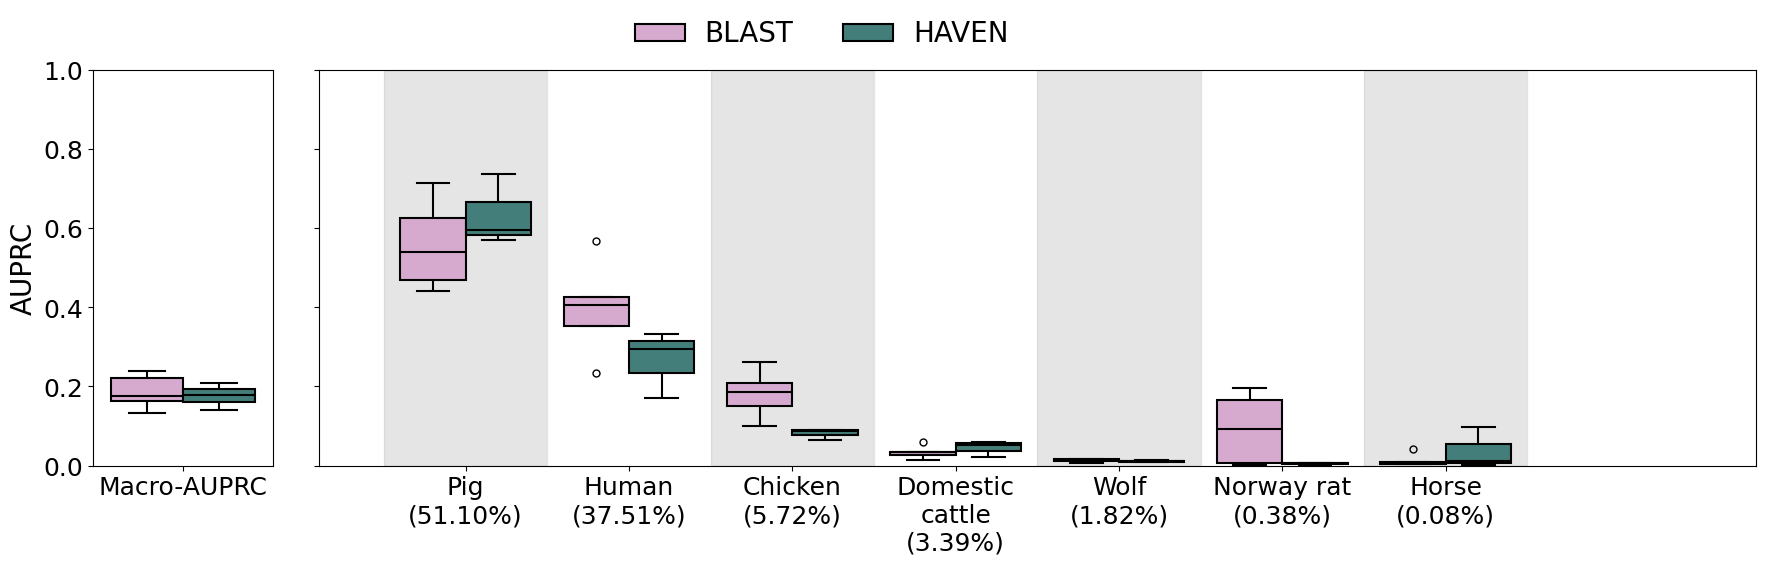

In [45]:
auprc_results_df = macro_and_classwise_auprc_analysis(output_filepaths, classes, None)

## Proteome-level Evaluation

Read output BLAST = (27078, 14)
Read output HAVEN = (8203, 11)


/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/bvbrc/../../../../src/utils/visualization_utils.py:119: UserWarning: set_ticklabels() should

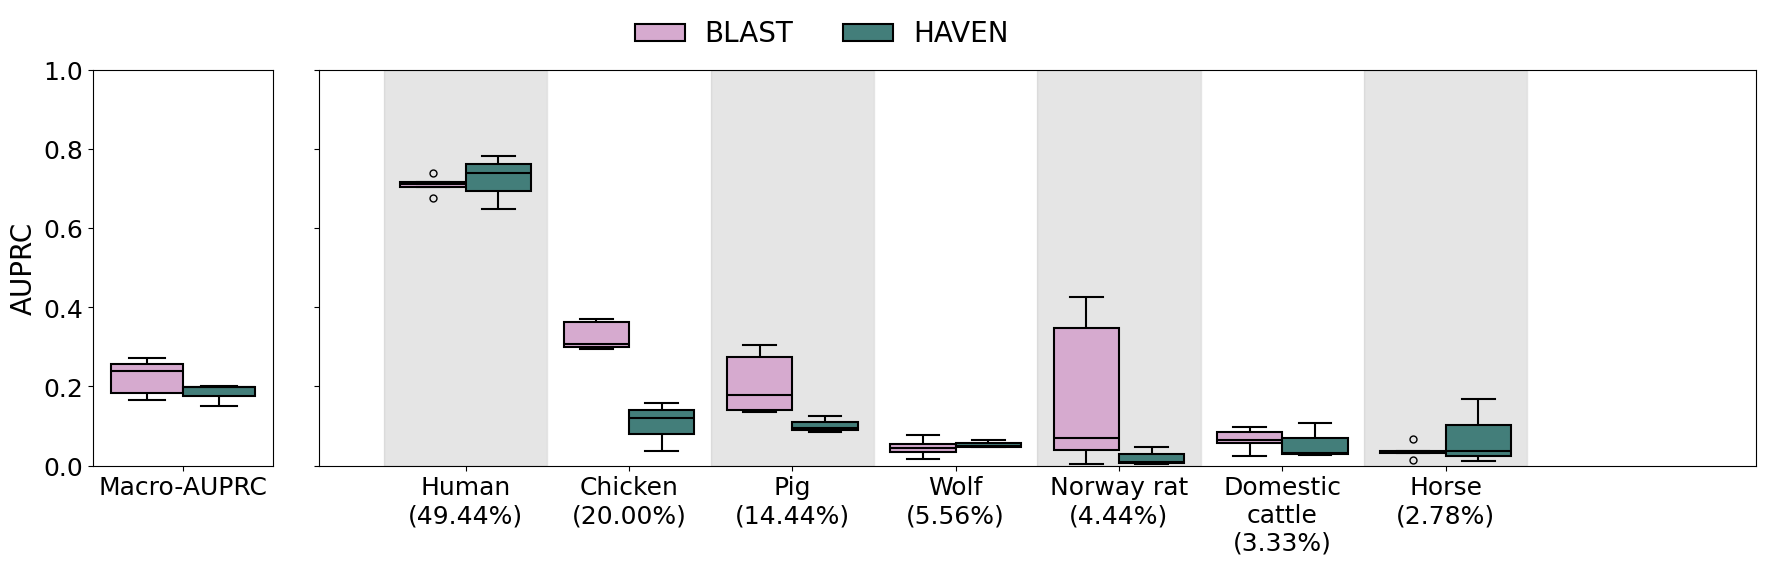

In [46]:
raw_results_df = macro_and_classwise_auprc_proteome_analysis(output_filepaths, classes, figure_output_filepath=None)

In [47]:
raw_results_df

,protein_id_name,itr,y_true,Human,Chicken,Pig,Domestic cattle,Norway rat,Horse,Wolf,Boa,proteome_id,protein,virus_host_species_tax_id,virus_genus_tax_name,model
0,AJZ77038.1_CP2475L,0,Pig,0.083828,0.130841,0.112708,0.137831,0.140533,0.124002,0.140533,0.129724,KM102979,CP2475L,9823,Asfivirus,BLAST
1,AJZ77039.1_NP1450L,0,Pig,0.086212,0.264342,0.093298,0.118306,0.082125,0.121044,0.119325,0.115349,KM102979,NP1450L,9823,Asfivirus,BLAST
2,AJZ77040.1_G1340L,0,Pig,0.096587,0.147658,0.112296,0.122994,0.124841,0.160655,0.103027,0.131941,KM102979,G1340L,9823,Asfivirus,BLAST
3,AJZ77041.1_M1249L,0,Pig,0.097754,0.084217,0.089933,0.138005,0.128476,0.238953,0.108616,0.114047,KM102979,M1249L,9823,Asfivirus,BLAST
4,AJZ77042.1_EP1242L,0,Pig,0.107618,0.133775,0.097764,0.139956,0.175618,0.119369,0.128563,0.097337,KM102979,EP1242L,9823,Asfivirus,BLAST
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8198,WQJ53339.1_lipoprotein,2,Pig,0.137149,0.023792,0.138922,0.068771,0.018779,0.023417,0.278685,0.310485,OR769223,lipoprotein,9823,NaN,HAVEN
8199,UVM99697.1_hypothetical-protein,2,Human,0.172449,0.146130,0.079280,0.115234,0.176298,0.166779,0.124037,0.019794,OP030980,hypothetical-protein,9606,NaN,HAVEN
8200,WQJ51234.1_hypothetical-protein,2,Pig,0.015294,0.000323,0.013233,0.007797,0.000138,0.000312,0.286830,0.676073,OR769219,hypothetical-protein,9823,NaN,HAVEN
8201,UVM99719.1_hypothetical-protein,2,Human,0.119820,0.109625,0.047487,0.153302,0.276299,0.166137,0.085142,0.042187,OP030980,hypothetical-protein,9606,NaN,HAVEN


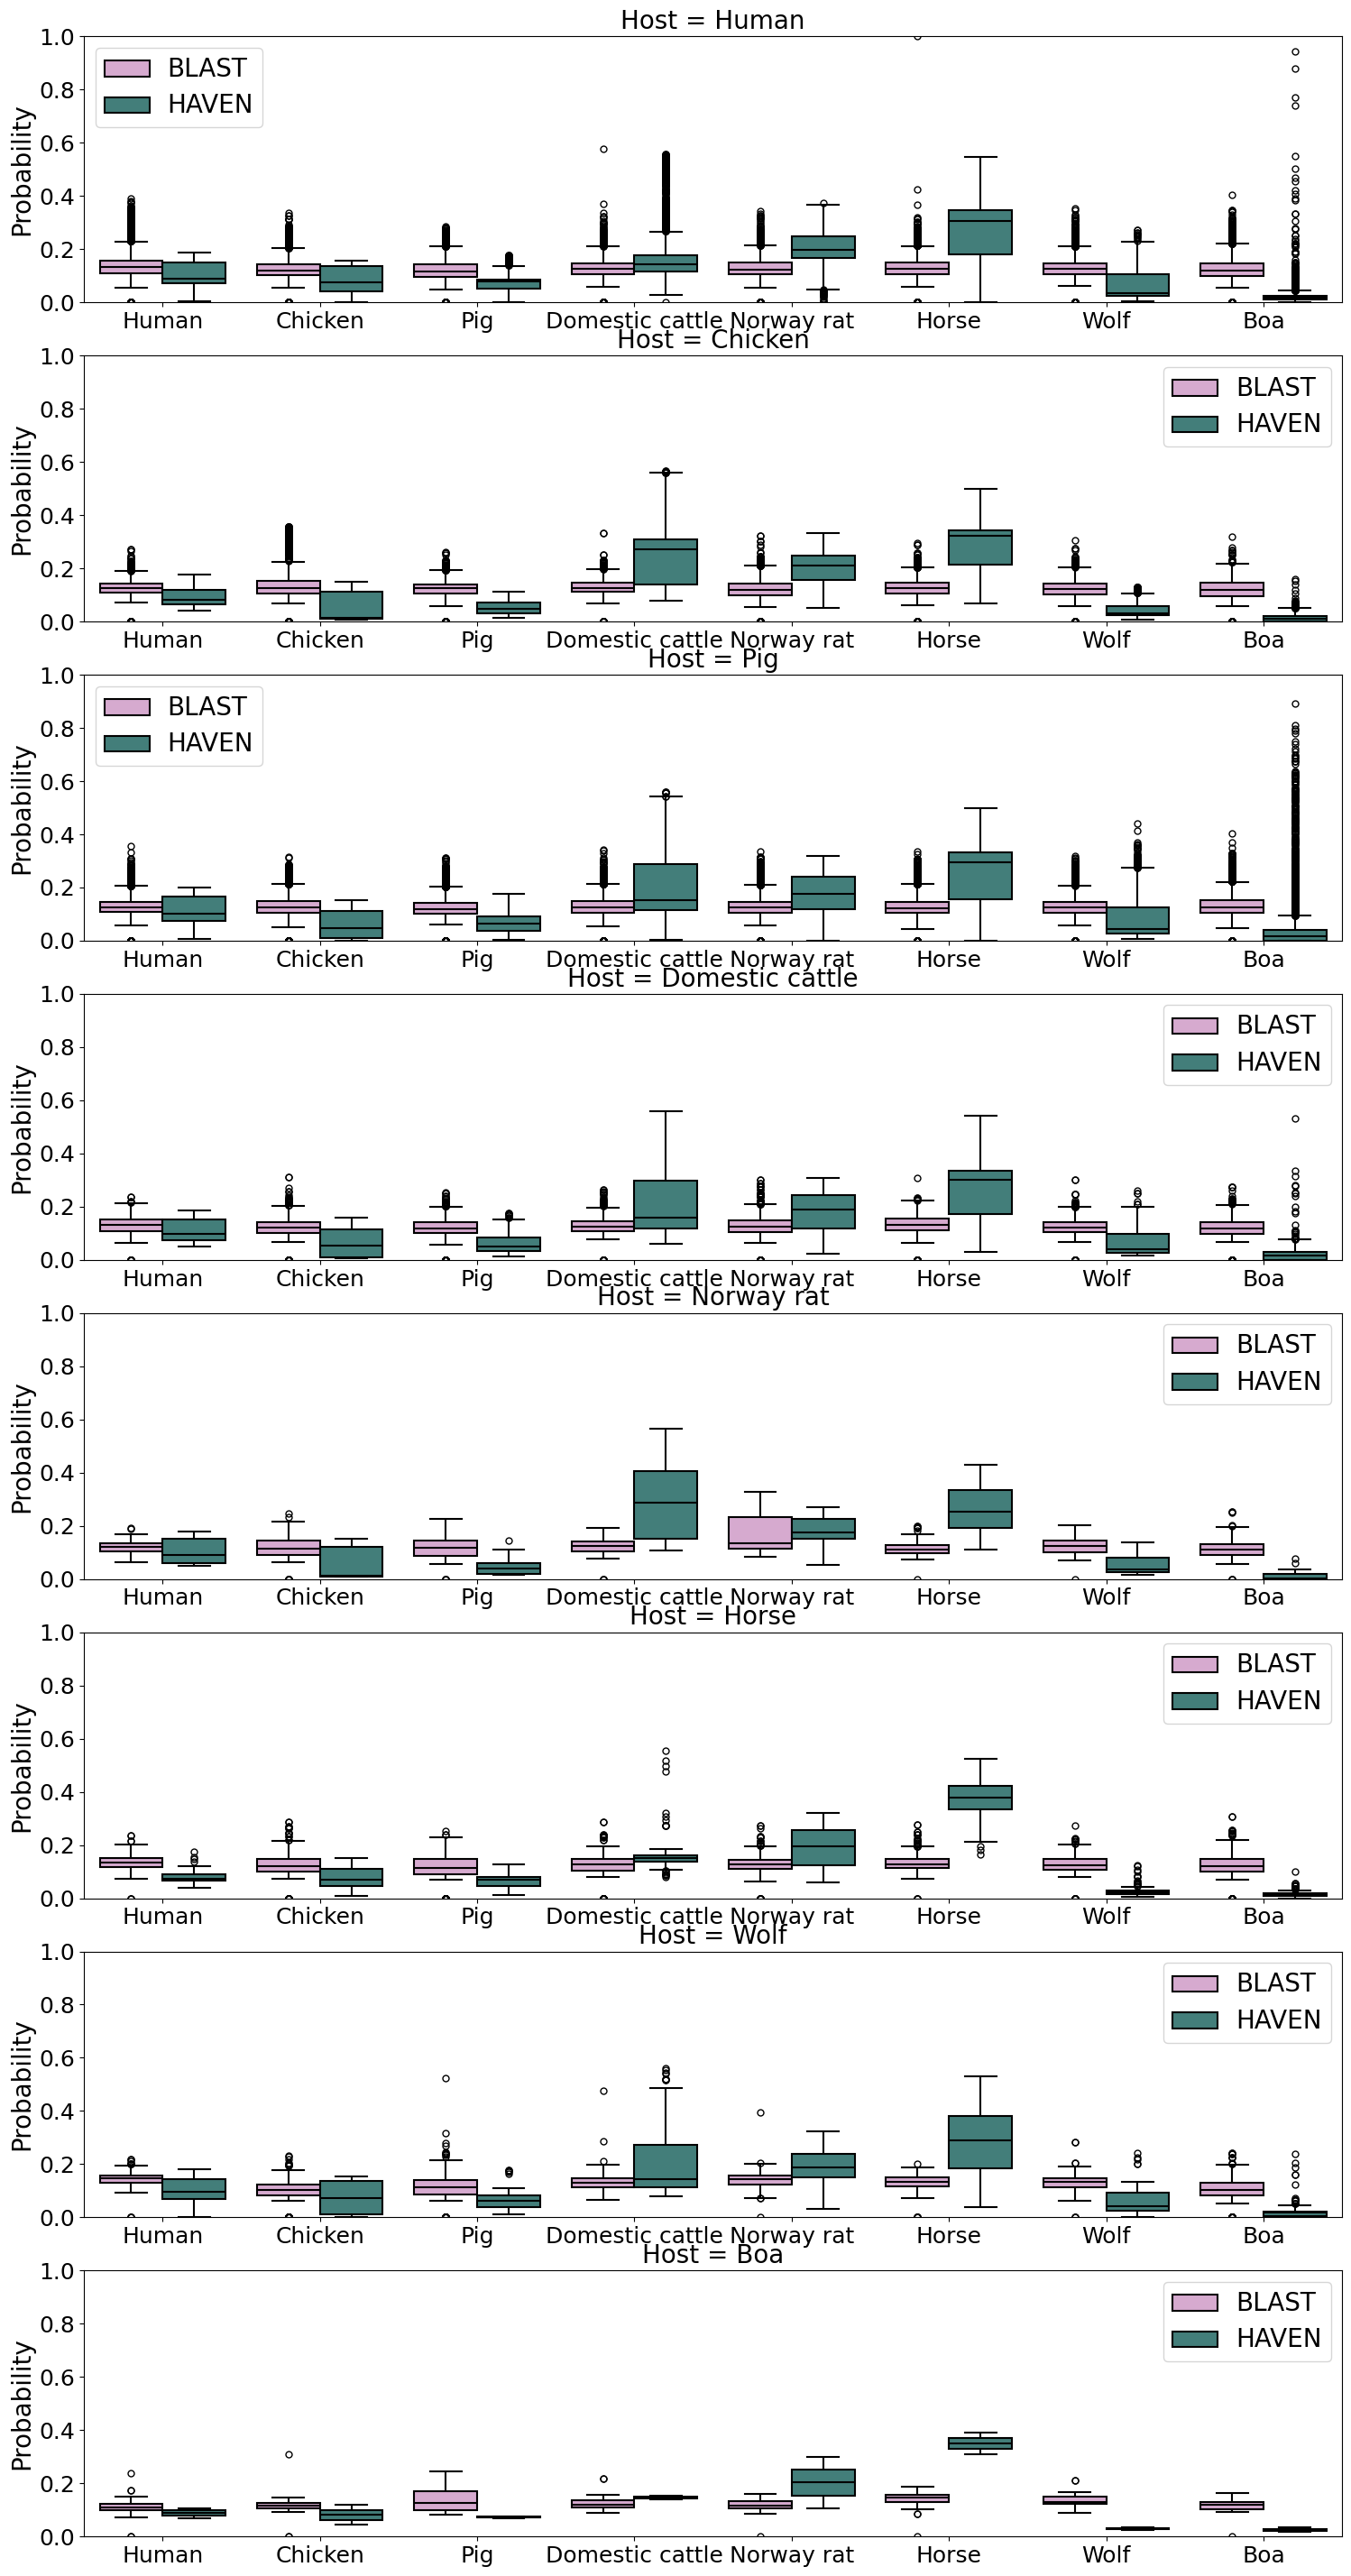

In [48]:
plot_df = raw_results_df.melt(id_vars=["proteome_id", "y_true", "itr", "model"], value_vars=classes, var_name="y_pred", value_name="probability")
plot_df.fillna(0, inplace=True)
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams.update({'font.size': 18})
fig, axs = plt.subplots(8, 1, figsize=(18, 36), sharex=False, sharey=True)
color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=auprc_results_df["model"].nunique())

for i, y_true_class in enumerate(classes):
    sns.boxplot(data=plot_df[plot_df["y_true"] == y_true_class], x="y_pred", y="probability", hue="model", fill=True,
                palette=color_palette, ax=axs[i],
                linewidth=1.5, fliersize=5, linecolor="black", )
    axs[i].set_xlabel("", size=0, labelpad=0)
    axs[i].set_ylabel("Probability", size=20)
    axs[i].set_ylim(0.0, 1)
    axs[i].set_title(f"Host = {y_true_class}", size=20)
    plt.setp(axs[i].get_legend().get_texts(), fontsize=20)
    axs[i].get_legend().set_title("")


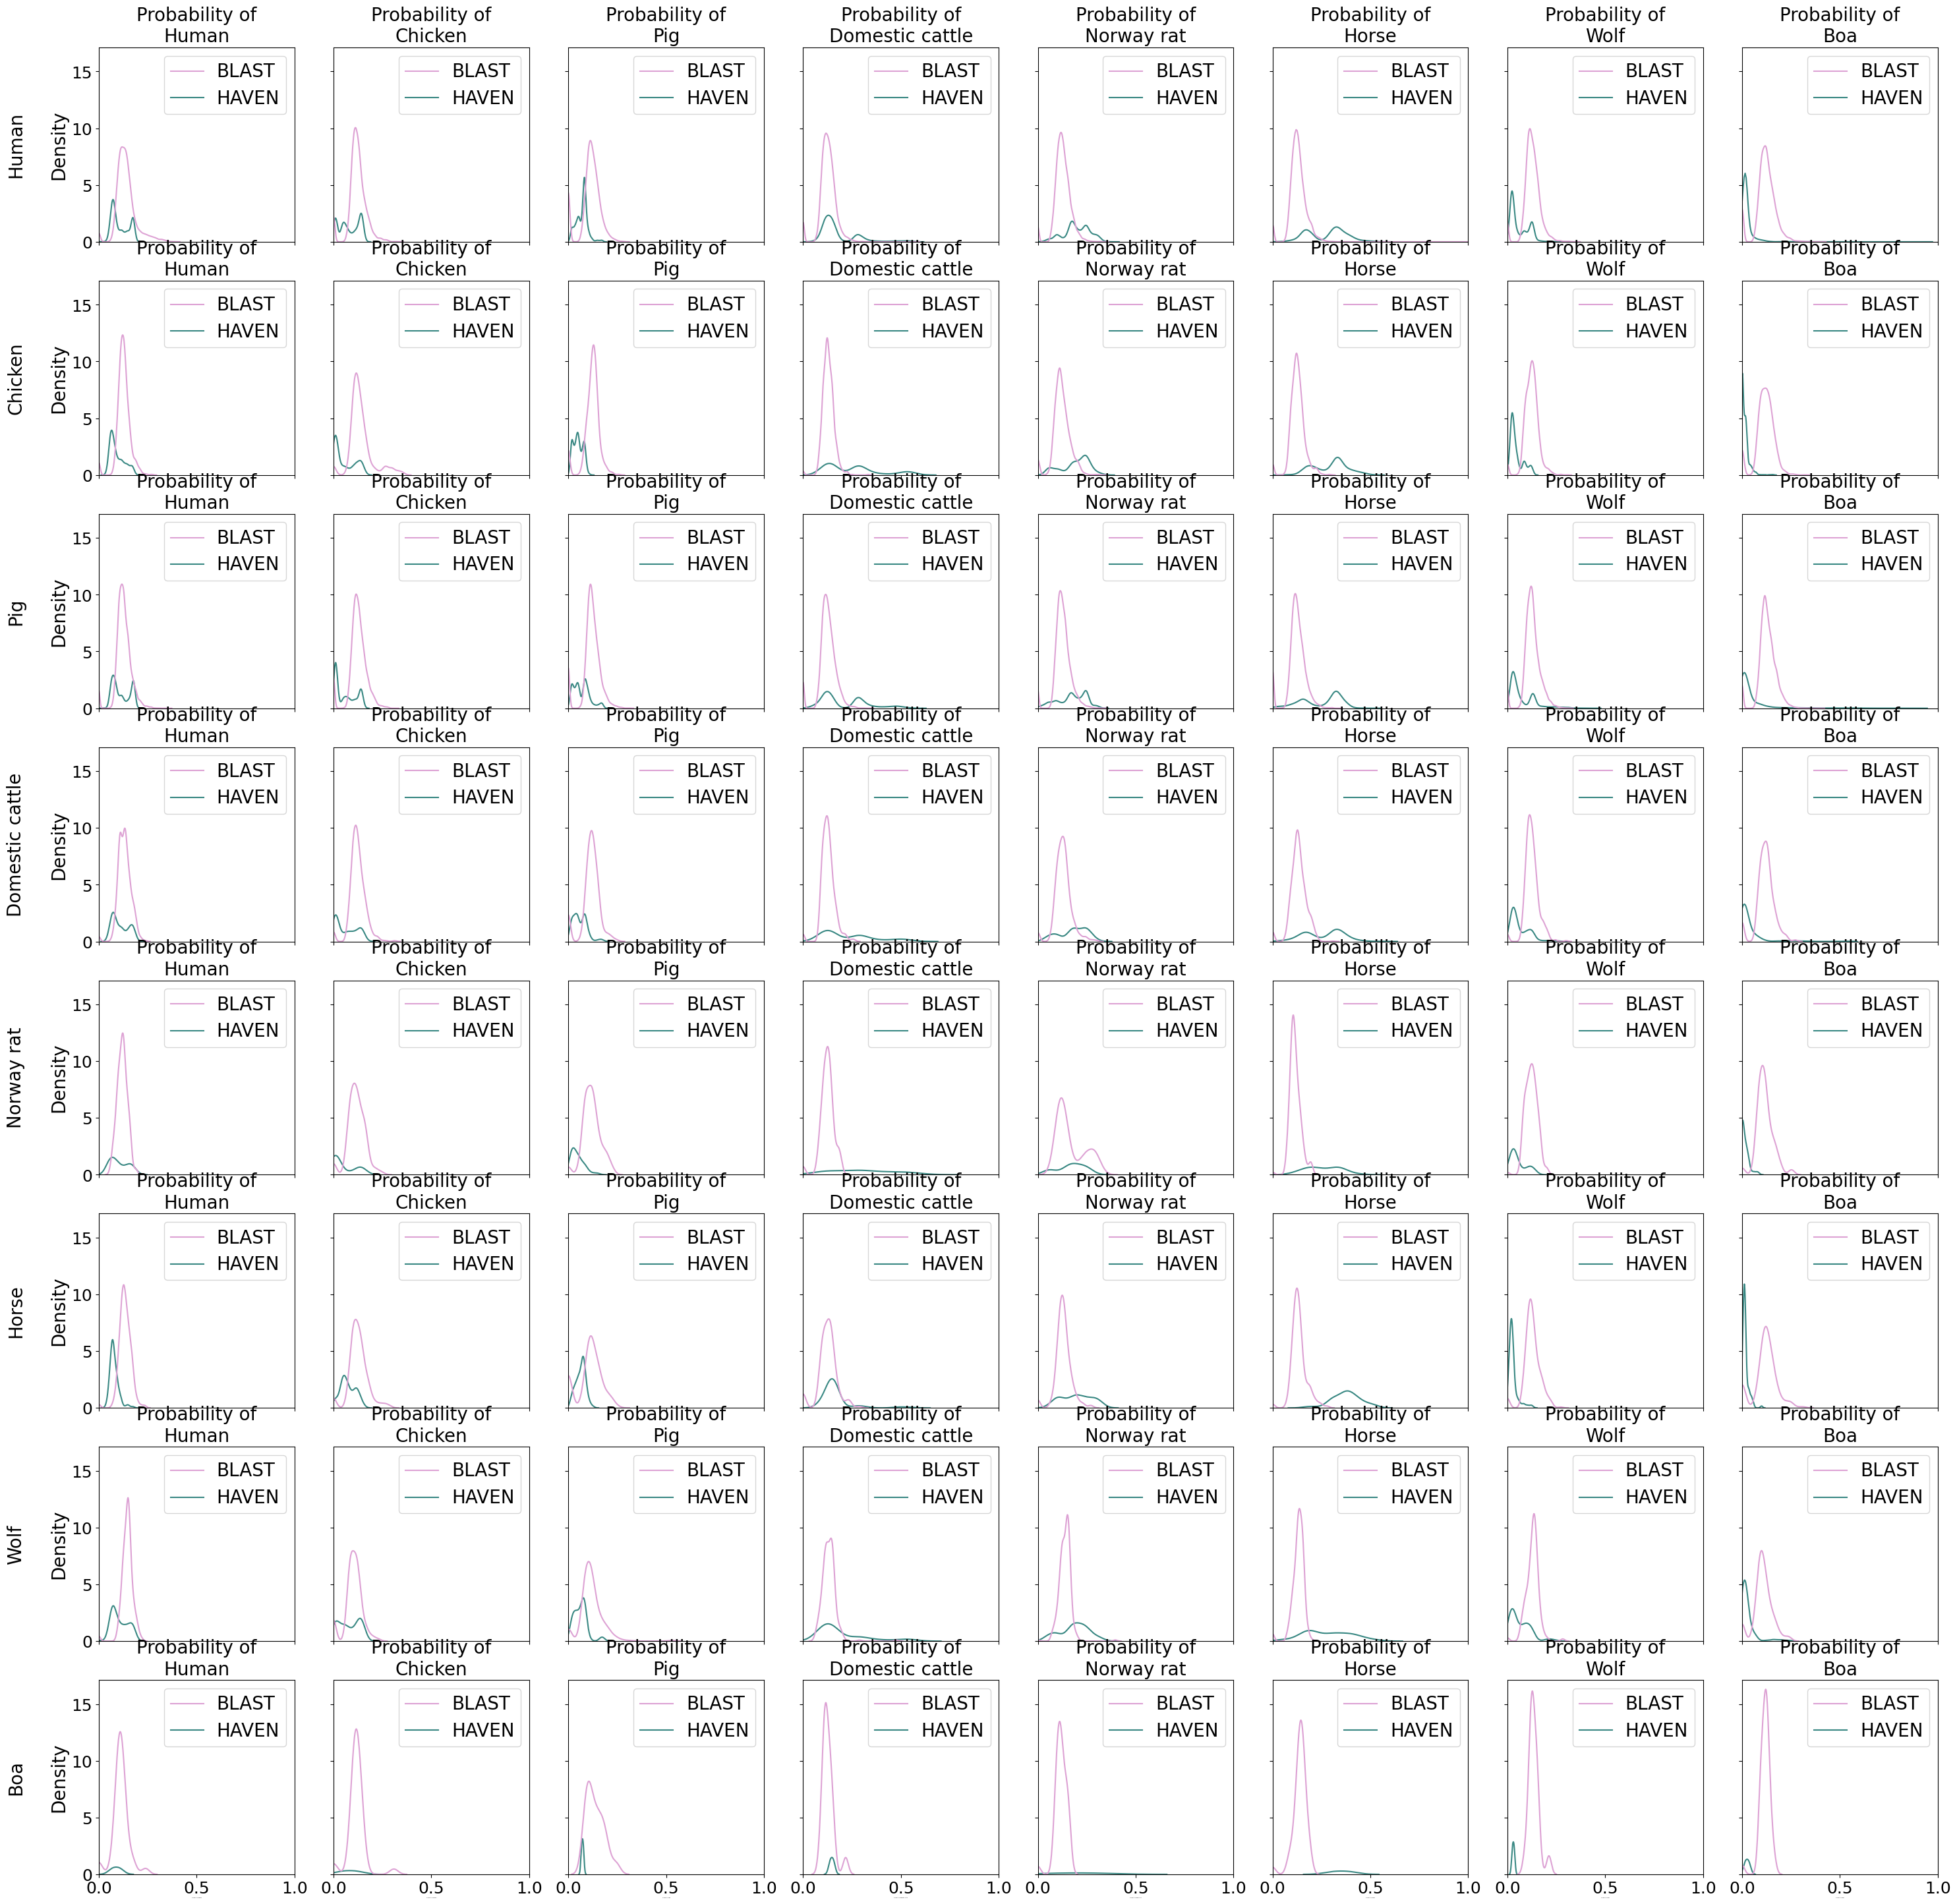

In [49]:
plot_df = raw_results_df.melt(id_vars=["proteome_id", "y_true", "itr", "model"], value_vars=classes, var_name="y_pred", value_name="probability")
plot_df.fillna(0, inplace=True)
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams.update({'font.size': 18})
fig, axs = plt.subplots(8, 8, figsize=(36, 36), sharex=True, sharey=True)
color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=auprc_results_df["model"].nunique())

for i, y_true_class in enumerate(classes):
    for j, y_pred_class in enumerate(classes):
        ax = axs[i][j]
        sns.kdeplot(data=plot_df[(plot_df["y_true"] == y_true_class) & (plot_df["y_pred"] == y_pred_class)], x="probability", hue="model", 
                    palette=color_palette, ax=ax,
                    linewidth=1.5)
        ax.set_xlabel(f"Probability of {y_pred_class}", size=0, labelpad=0)
        ax.set_ylabel(f"{y_true_class}\n\nDensity", size=20)
        ax.set_title(f"Probability of\n{y_pred_class}", size=20)
        ax.set_xlim(0.0, 1)
        plt.setp(ax.get_legend().get_texts(), fontsize=20)
        ax.get_legend().set_title("")


#### Analysis of predictions for Gammainfluenzavirus

In [50]:
def analyse_virus_genus_predictions_per_proteome(raw_results_df, virus_genus, model_name):
    plot_df = raw_results_df[(raw_results_df["virus_genus_tax_name"] == virus_genus) & (raw_results_df["model"] == model_name)]
    print(plot_df.shape)
    proteomes = plot_df["proteome_id"].unique()
    n_proteomes = len(proteomes)
    n_proteins = plot_df["protein"].value_counts().shape[0]
    plt.rcParams['xtick.labelsize'] = 10
    plt.rcParams['ytick.labelsize'] = 10
    plt.rcParams.update({'font.size': 10})
    fig, axs = plt.subplots(n_proteomes, 1, figsize=(8, n_proteomes*n_proteins/2), sharex=True, sharey=False)
    
    for i, proteome in enumerate(proteomes):
        ax = axs[i]
        y_true_class = plot_df[plot_df["proteome_id"] == proteome]["y_true"].unique()[0]
        heatmap_df = plot_df[plot_df["proteome_id"] == proteome]
        itr = heatmap_df["itr"].unique()[0]
        heatmap_df = heatmap_df[heatmap_df["itr"] == itr][classes + ["protein"]].set_index("protein")
        heatmap_df.fillna(0, inplace=True)
        sns.heatmap(heatmap_df, ax=ax, linewidth=2,
                    annot=True, fmt=".2f",
                    vmin=0, vmax=1,
                    cmap="crest", alpha=.9,
                   cbar_kws={"aspect": 10})
        ax.set_title(f"Proteome:{proteome}\nHost:{y_true_class}", size=10)
        ax.set(xlabel="", ylabel="")

(20, 16)


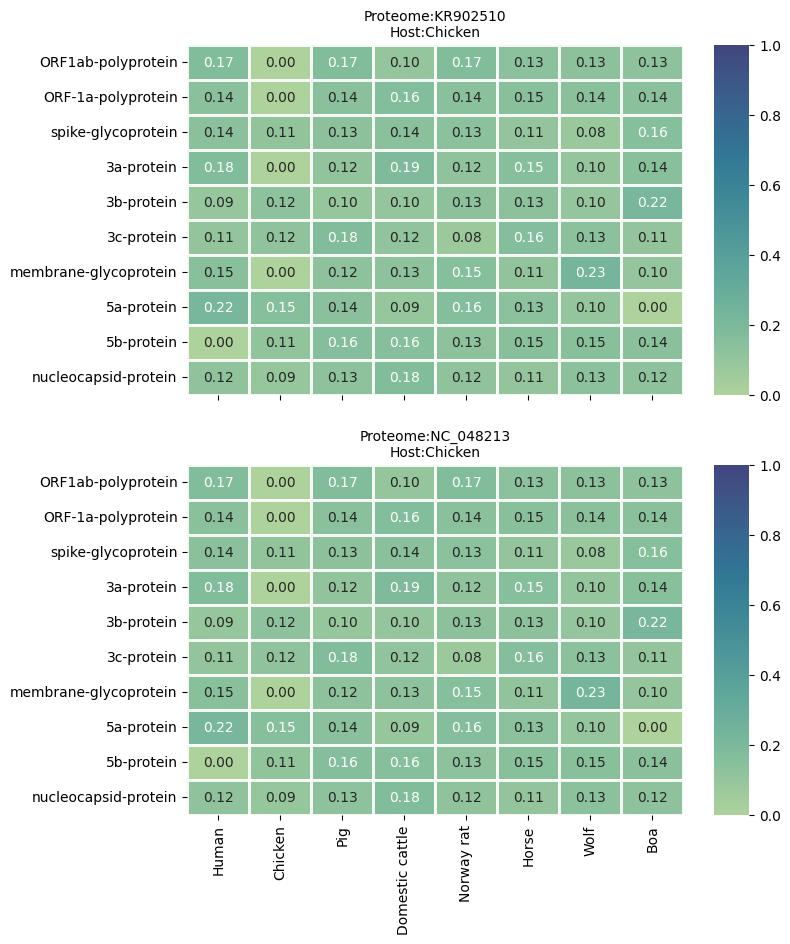

In [51]:
virus_genus = "Gammacoronavirus"
model_name = "BLAST"
analyse_virus_genus_predictions_per_proteome(raw_results_df, virus_genus, model_name)

In [52]:
virus_genus = "Gammacoronavirus"
model_name = "HAVEN"
analyse_virus_genus_predictions_per_proteome(raw_results_df, virus_genus, model_name)

(0, 16)


ValueError: Number of rows must be a positive integer, not 0

<Figure size 800x0 with 0 Axes>

In [34]:
def analyse_virus_genus_predictions_per_host(raw_results_df, virus_genus):
    plot_df = raw_results_df[(raw_results_df["virus_genus_tax_name"] == virus_genus) & (raw_results_df["model"] == model_name)]
    hosts = plot_df["y_true"].unique()
    plt.rcParams['xtick.labelsize'] = 16
    plt.rcParams['ytick.labelsize'] = 16
    plt.rcParams.update({'font.size': 16})
    color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=auprc_results_df["model"].nunique())

    for i, host in enumerate(hosts):
        host_df = plot_df[plot_df["y_true"] == host]
        proteins = host_df["protein"].unique()
        print(f"Host = {host}, proteins = {len(proteins)}")
        fig, axs = plt.subplots(1, len(proteins), figsize=(len(proteins)*4, 4), sharex=True, sharey=True)
        for j, protein in enumerate(proteins):
            ax = axs[j]
            host_protein_df = host_df[host_df["protein"] == protein][classes + ["proteome_id", "itr", "model"]]
            barplot_df = host_protein_df.melt(id_vars=["proteome_id", "itr", "model"], value_vars=classes, var_name="y_pred", value_name="probability")
            sns.barplot(barplot_df, x="probability", y="y_pred", hue="model", ax=ax, orient="h", palette=color_palette)
            ax.set_title(f"{protein}", size=10)
            ax.set(ylabel=f"True Host:{host}\n", xlabel=f"Probability")
            ax.set_xlim(0.0, 1)
            plt.setp(ax.get_legend().get_texts(), fontsize=16)
            ax.get_legend().set_title("")
        plt.show()

Host = Chicken, proteins = 10


/tmp/ipykernel_2145540/1628817997.py:18: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.barplot(barplot_df, x="probability", y="y_pred", hue="model", ax=ax, orient="h", palette=color_palette)
/tmp/ipykernel_2145540/1628817997.py:18: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.barplot(barplot_df, x="probability", y="y_pred", hue="model", ax=ax, orient="h", palette=color_palette)
/tmp/ipykernel_2145540/1628817997.py:18: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.barplot(barplot_df, x="probability", y="y_pred", hue="model", ax=ax, orient="h", palette=color_palette)
/tmp/ipykernel_2145540/1628817997.py:18: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.barplot(barplot_df, x="probability", y="y_pred", hue="model", ax=ax, orient="h", palette=color_palette)
/tmp/ipykernel_21455

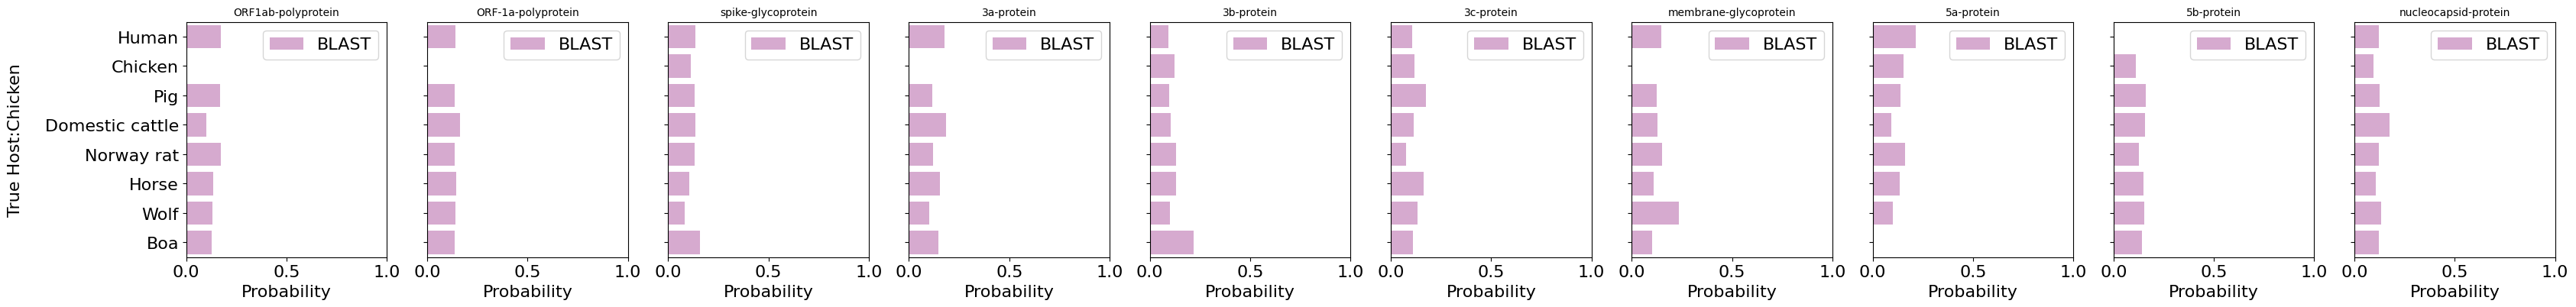

In [35]:
virus_genus = "Gammacoronavirus"
analyse_virus_genus_predictions_per_host(raw_results_df, virus_genus)

In [53]:
raw_results_df[raw_results_df["model"] == "HAVEN"]

,protein_id_name,itr,y_true,Human,Chicken,Pig,Domestic cattle,Norway rat,Horse,Wolf,Boa,proteome_id,protein,virus_host_species_tax_id,virus_genus_tax_name,model
0,YP_009041999.1_ORF20,0,Domestic cattle,0.060544,0.008065,0.052362,0.272385,0.249635,0.333453,0.023493,0.000062,NC_024303,ORF20,9913,Macavirus,HAVEN
1,WQJ53532.1_1-(5-phosphoribosyl)-5-[(5-phosphor...,0,Pig,0.066040,0.008640,0.048549,0.274409,0.250187,0.324129,0.027948,0.000097,OR769223,1-(5-phosphoribosyl)-5-[(5-phosphoribosylamino...,9823,NaN,HAVEN
2,WQJ51640.1_hypothetical-protein,0,Pig,0.059781,0.007744,0.054829,0.274541,0.248489,0.333203,0.021362,0.000052,OR769219,hypothetical-protein,9823,NaN,HAVEN
3,ANJ02408.1_ORF12,0,Chicken,0.067680,0.008926,0.045090,0.276277,0.246879,0.323635,0.031384,0.000129,KT862807,ORF12,9031,Aviadenovirus,HAVEN
4,WQJ53227.1_hypothetical-protein,0,Pig,0.073047,0.009336,0.042785,0.277479,0.248195,0.313952,0.035028,0.000178,OR769223,hypothetical-protein,9823,NaN,HAVEN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8198,WQJ53339.1_lipoprotein,2,Pig,0.137149,0.023792,0.138922,0.068771,0.018779,0.023417,0.278685,0.310485,OR769223,lipoprotein,9823,NaN,HAVEN
8199,UVM99697.1_hypothetical-protein,2,Human,0.172449,0.146130,0.079280,0.115234,0.176298,0.166779,0.124037,0.019794,OP030980,hypothetical-protein,9606,NaN,HAVEN
8200,WQJ51234.1_hypothetical-protein,2,Pig,0.015294,0.000323,0.013233,0.007797,0.000138,0.000312,0.286830,0.676073,OR769219,hypothetical-protein,9823,NaN,HAVEN
8201,UVM99719.1_hypothetical-protein,2,Human,0.119820,0.109625,0.047487,0.153302,0.276299,0.166137,0.085142,0.042187,OP030980,hypothetical-protein,9606,NaN,HAVEN


In [54]:
raw_results_df[raw_results_df["model"] == "BLAST"]

,protein_id_name,itr,y_true,Human,Chicken,Pig,Domestic cattle,Norway rat,Horse,Wolf,Boa,proteome_id,protein,virus_host_species_tax_id,virus_genus_tax_name,model
0,AJZ77038.1_CP2475L,0,Pig,0.083828,0.130841,0.112708,0.137831,0.140533,0.124002,0.140533,0.129724,KM102979,CP2475L,9823,Asfivirus,BLAST
1,AJZ77039.1_NP1450L,0,Pig,0.086212,0.264342,0.093298,0.118306,0.082125,0.121044,0.119325,0.115349,KM102979,NP1450L,9823,Asfivirus,BLAST
2,AJZ77040.1_G1340L,0,Pig,0.096587,0.147658,0.112296,0.122994,0.124841,0.160655,0.103027,0.131941,KM102979,G1340L,9823,Asfivirus,BLAST
3,AJZ77041.1_M1249L,0,Pig,0.097754,0.084217,0.089933,0.138005,0.128476,0.238953,0.108616,0.114047,KM102979,M1249L,9823,Asfivirus,BLAST
4,AJZ77042.1_EP1242L,0,Pig,0.107618,0.133775,0.097764,0.139956,0.175618,0.119369,0.128563,0.097337,KM102979,EP1242L,9823,Asfivirus,BLAST
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27073,YP_006504092.1_nucleocapsid-protein,4,Human,0.155222,0.109358,0.123864,0.178035,0.115605,0.115605,0.101156,0.101156,NC_018137,nucleocapsid-protein,9606,Bandavirus,BLAST
27074,YP_006504093.1_nonstructural-protein,4,Human,0.144161,0.107965,0.161637,0.119208,NaN,0.154270,0.153817,0.158943,NC_018137,nonstructural-protein,9606,Bandavirus,BLAST
27075,YP_006504094.1_membrane-glycoprotein-polyprotein,4,Human,0.091060,0.092827,0.145613,0.098081,0.102110,0.175882,0.163376,0.131050,NC_018138,membrane-glycoprotein-polyprotein,9606,Bandavirus,BLAST
27076,YP_006519138.1_Gn-protein,4,Human,0.148701,0.155584,NaN,0.164390,0.233376,0.142365,0.155584,NaN,NC_018138,Gn-protein,9606,Bandavirus,BLAST


In [55]:
input_df[input_df["proteome_id"] == "OR769223"]

,proteome_id,protein_id,protein,protein_id_name,virus_host_species_tax_id,virus_host_species_tax_name,virus_genus_tax_name,virus_species_tax_name,sequence,is_nucleotide
8720,OR769223,WQJ53225.1,hypothetical-protein,WQJ53225.1_hypothetical-protein,9823,Sus scrofa,NaN,phage Lak_Megaphage_Sonny,MQNMNLYKKIYEAINTGIQNALALDDEDVSIIYQHKKISNDFDSNE...,False
8721,OR769223,WQJ53226.1,tail-tube,WQJ53226.1_tail-tube,9823,Sus scrofa,NaN,phage Lak_Megaphage_Sonny,MILNPLSQNFAIWMPANFFYNEVVNLWMPVFKRKFLPYITIEDMFA...,False
8722,OR769223,WQJ53227.1,hypothetical-protein,WQJ53227.1_hypothetical-protein,9823,Sus scrofa,NaN,phage Lak_Megaphage_Sonny,MNLYNKIYEAINIGIQKALVLDDEDDVSIIYQHKKIINNSNVISYL...,False
8723,OR769223,WQJ53228.1,hypothetical-protein,WQJ53228.1_hypothetical-protein,9823,Sus scrofa,NaN,phage Lak_Megaphage_Sonny,MKDLQKIYEAINAGIQKALALNDEDDVSIIYQHKKIVNNSNVISYY...,False
8724,OR769223,WQJ53229.1,hypothetical-protein,WQJ53229.1_hypothetical-protein,9823,Sus scrofa,NaN,phage Lak_Megaphage_Sonny,MKNLYKKLYEAINTGIQKALVLDDDEDVSIIYQHSKIVNNTNLMPY...,False
...,...,...,...,...,...,...,...,...,...,...
9454,OR769223,WQJ53959.1,hypothetical-protein,WQJ53959.1_hypothetical-protein,9823,Sus scrofa,NaN,phage Lak_Megaphage_Sonny,MKHLYNKIYEAINTGIQKALALDDGEDVSINYQHKKISNDFNIDKL...,False
9455,OR769223,WQJ53960.1,hypothetical-protein,WQJ53960.1_hypothetical-protein,9823,Sus scrofa,NaN,phage Lak_Megaphage_Sonny,MKNLYKKLYEAINTGIQRALALDDDEDVSINYQHKKISNDFDSNEF...,False
9456,OR769223,WQJ53961.1,hypothetical-protein,WQJ53961.1_hypothetical-protein,9823,Sus scrofa,NaN,phage Lak_Megaphage_Sonny,MKHLYKKIYEAINTGIQNALTLDDEDVSIIYQHKKIVNNSNVIPYY...,False
9457,OR769223,WQJ53962.1,hypothetical-protein,WQJ53962.1_hypothetical-protein,9823,Sus scrofa,NaN,phage Lak_Megaphage_Sonny,MKHLYKKLYEAINAGIQKALVLDDEGDVSIIYQHKKISNDFNSNEF...,False
